---

## 10. Histogram — For Distribution 📊

**When to use:** When you want to see **how values are distributed** — are they clustered, spread out, or skewed?  
**Business question:** *"How is revenue distributed across all transactions?"*

**Histogram vs Bar Chart — What's the difference?**
| Feature | Bar Chart | Histogram |
|---|---|---|
| Used for | Comparing categories | Showing distribution of numbers |
| X-axis | Category labels (Product, City) | Number ranges (bins) |
| Bars touch? | No (gaps between bars) | Yes (bars are connected) |

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [66]:
df = pd.read_excel("DataSet_used\\sales_data.xlsx")

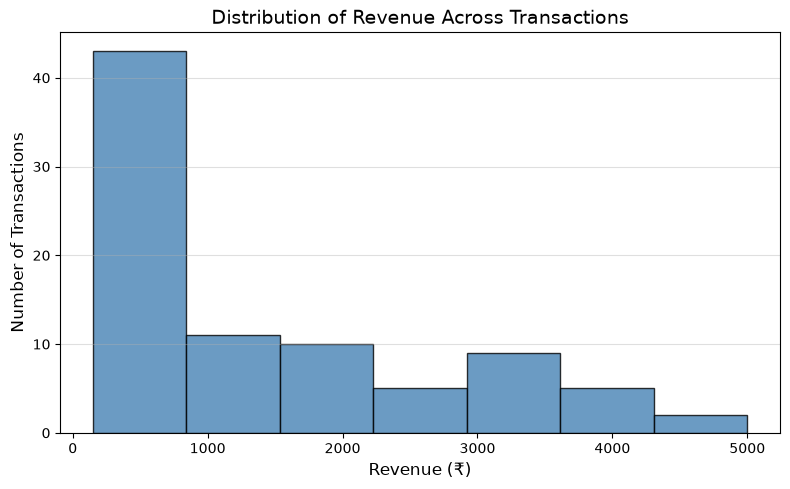

In [67]:
# ============================================
# HISTOGRAM: Distribution of Revenue
# ============================================

plt.figure(figsize=(8, 5))

# bins = number of equal-width buckets to divide the data into
plt.hist(df['Revenue'], bins=7, color='steelblue', edgecolor='black', alpha=0.8)

plt.xlabel('Revenue (₹)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Distribution of Revenue Across Transactions', fontsize=14)
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 📝 How to Read This Chart

- The **x-axis** shows revenue ranges (bins).
- The **y-axis** shows how many transactions fall in each range.
- If most bars are on the **left side**, the data is **right-skewed** (most transactions have lower revenue, a few have very high).
- A **symmetric** histogram looks like a bell curve.

### 💡 Sample Business Insight

> *"Most transactions generate revenue in the lower range (under ₹2000). A few transactions with high-priced products like Laptops push the tail to the right. This right-skewed distribution is common in retail."*

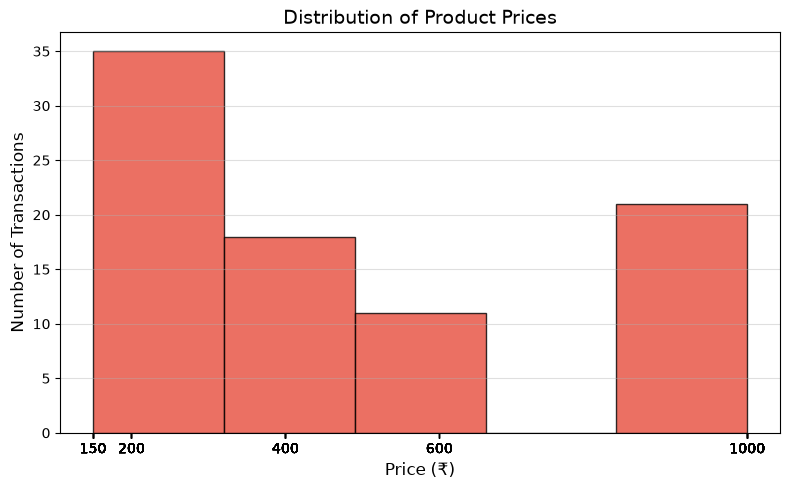

In [68]:
# ============================================
# HISTOGRAM #2: Distribution of Price
# ============================================

plt.figure(figsize=(8, 5))

# Trying different number of bins
plt.hist(df['Price'], bins=5, color='#e74c3c', edgecolor='black', alpha=0.8)

plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Distribution of Product Prices', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.xticks(df["Price"])
plt.tight_layout()
plt.show()

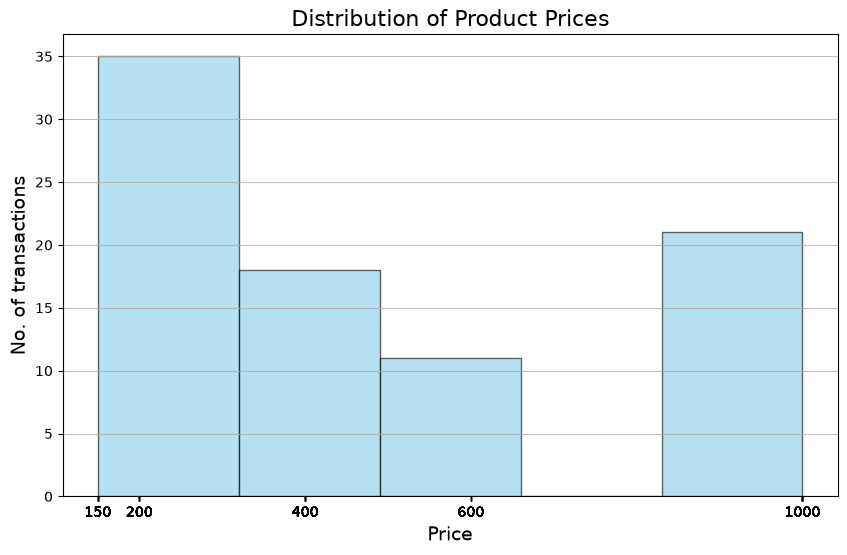

In [69]:
plt.figure(figsize = (10,6))

plt.hist(df['Price'], bins = 5, edgecolor = 'black', alpha= 0.6, color = 'skyblue')
plt.xlabel("Price", fontsize = 14)
plt.ylabel("No. of transactions", fontsize = 14)
plt.title("Distribution of Product Prices", fontsize = 16)
plt.xticks(df["Price"])
plt.grid(axis='y', alpha = 0.8)
plt.show()

---

## 11. Boxplot — For Detecting Outliers 📦

**When to use:** When you want to see the **spread of data** and **detect outliers** (unusually high or low values).  
**Business question:** *"Are there any unusually high or low revenue transactions?"*

### Anatomy of a Boxplot:

```
    o           ← Outlier (dot above the whisker)
    |
  ──┬──         ← Maximum (within normal range)
  │   │
  │   │         ← Upper Quartile (Q3 — 75th percentile)
  ├───┤
  │───│         ← Median (Q2 — 50th percentile)
  ├───┤
  │   │         ← Lower Quartile (Q1 — 25th percentile)
  │   │
  ──┴──         ← Minimum (within normal range)
```

- The **box** covers the middle 50% of data (between Q1 and Q3).
- The **line inside** the box is the median.
- The **whiskers** extend to the smallest/largest non-outlier values.
- Any **dots beyond the whiskers** are outliers.

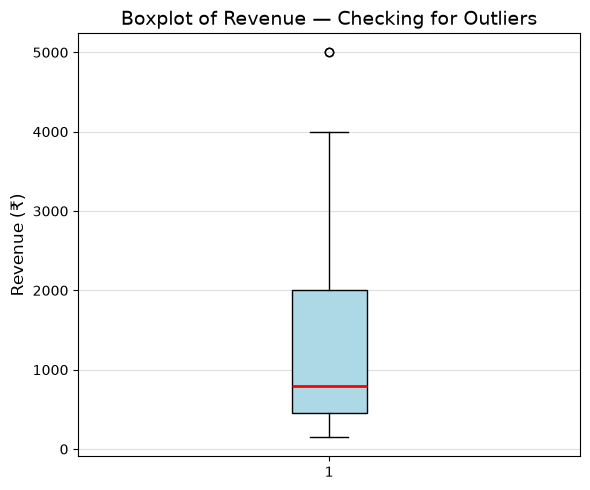

800.0


In [70]:
# ============================================
# BOXPLOT: Revenue distribution
# ============================================

plt.figure(figsize=(6, 5))

# Create boxplot
plt.boxplot(df['Revenue'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

# patch_artist=True allows fill color

plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Boxplot of Revenue — Checking for Outliers', fontsize=14)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()
print(df["Revenue"].median())

### 📝 How to Read This Chart

- The **red line** inside the box is the **median** revenue.
- The **box** shows where the middle 50% of transactions fall.
- **Dots above or below the whiskers** are potential outliers.
- If there are no dots outside the whiskers, there are no extreme outliers.

### 💡 Sample Business Insight

> *"The median transaction revenue is around ₹900. Most transactions fall between ₹450 and ₹2000. Any transactions beyond the whiskers can be investigated — they may be bulk orders or data entry errors."*

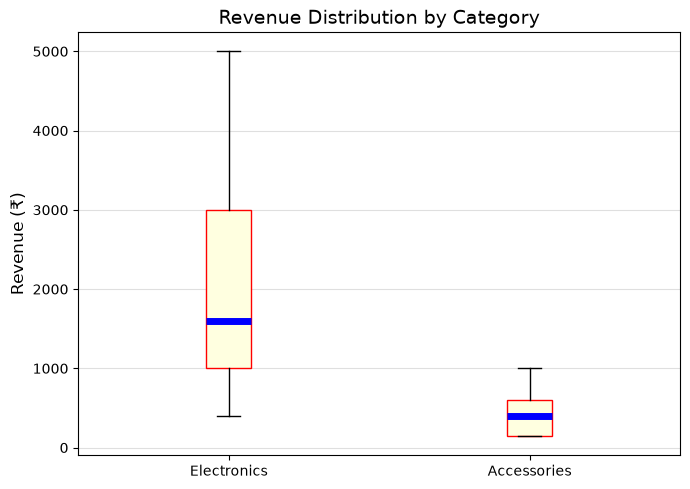

In [71]:
# ============================================
# BOXPLOT #2: Revenue distribution by Category
# ============================================

# Prepare data for each category
electronics_rev = df[df['Category'] == 'Electronics']['Revenue']
accessories_rev = df[df['Category'] == 'Accessories']['Revenue']

plt.figure(figsize=(7, 5))

plt.boxplot([electronics_rev, accessories_rev],
            tick_labels=['Electronics', 'Accessories'],
            patch_artist=True,
            boxprops=dict(facecolor='lightyellow', color='red'),
            medianprops=dict(color='blue', linewidth=5))

plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Revenue Distribution by Category', fontsize=14)
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 💡 Sample Business Insight

> *"Electronics has a much wider revenue range than Accessories, which makes sense since it includes both mid-range products (Smartwatch) and high-end products (Laptop). Accessories revenue is more concentrated in the lower range."*

---

## 12. Making Charts More Professional — Labels, Legend, Grid

Let's combine everything we've learned to make one clean, professional chart.

**The checklist for every chart you create:**
- ✅ `plt.figure(figsize=())` — Set size
- ✅ `plt.xlabel()` — Label x-axis  
- ✅ `plt.ylabel()` — Label y-axis
- ✅ `plt.title()` — Give it a clear title
- ✅ `plt.legend()` — Add legend (when multiple lines/bars)
- ✅ `plt.grid()` — Add gridlines for readability
- ✅ `plt.tight_layout()` — Prevent labels from getting cut off
- ✅ `plt.show()` — Display the chart

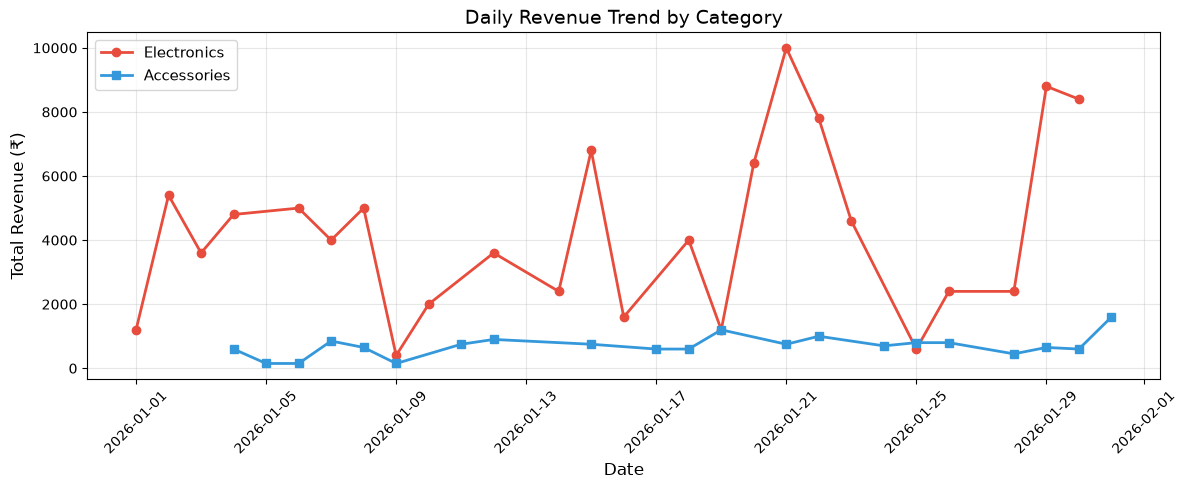

In [72]:
# ============================================
# COMPLETE EXAMPLE: Line chart with all elements
# ============================================

# Prepare data: Daily revenue split by category
electronics_daily = df[df['Category'] == 'Electronics'].groupby('Date')['Revenue'].sum()
accessories_daily = df[df['Category'] == 'Accessories'].groupby('Date')['Revenue'].sum()


# Create the chart
plt.figure(figsize=(12, 5))

# Plot two lines — using 'label' parameter for the legend
plt.plot(electronics_daily.index, electronics_daily.values,
         color='#e74c3c', marker='o', linewidth=2, label='Electronics')

plt.plot(accessories_daily.index, accessories_daily.values,
         color='#3498db', marker='s', linewidth=2, label='Accessories')

# Add all professional elements
plt.xlabel('Date', fontsize=12)                         # X-axis label
plt.ylabel('Total Revenue (₹)', fontsize=12)            # Y-axis label
plt.title('Daily Revenue Trend by Category', fontsize=14)  # Title
plt.legend(fontsize=11)                                 # Show legend
plt.grid(True, alpha=0.3)                               # Gridlines
plt.xticks(rotation=45)                                 # Rotate date labels
plt.tight_layout()                                      # Fix layout

plt.show()

### 💡 Sample Business Insight

> *"Electronics consistently generates higher daily revenue than Accessories. Both categories show fluctuations, but Electronics has more pronounced peaks — likely driven by high-value Laptop and Smartphone sales."*

---

## 13. (Optional) Basic Subplots — Showing Multiple Charts Side by Side

Sometimes you want to show two charts **next to each other** for comparison.  
We use `plt.subplot()` for this. Don't worry about memorizing the syntax — just understand the concept.

**Syntax:** `plt.subplot(rows, columns, position)`

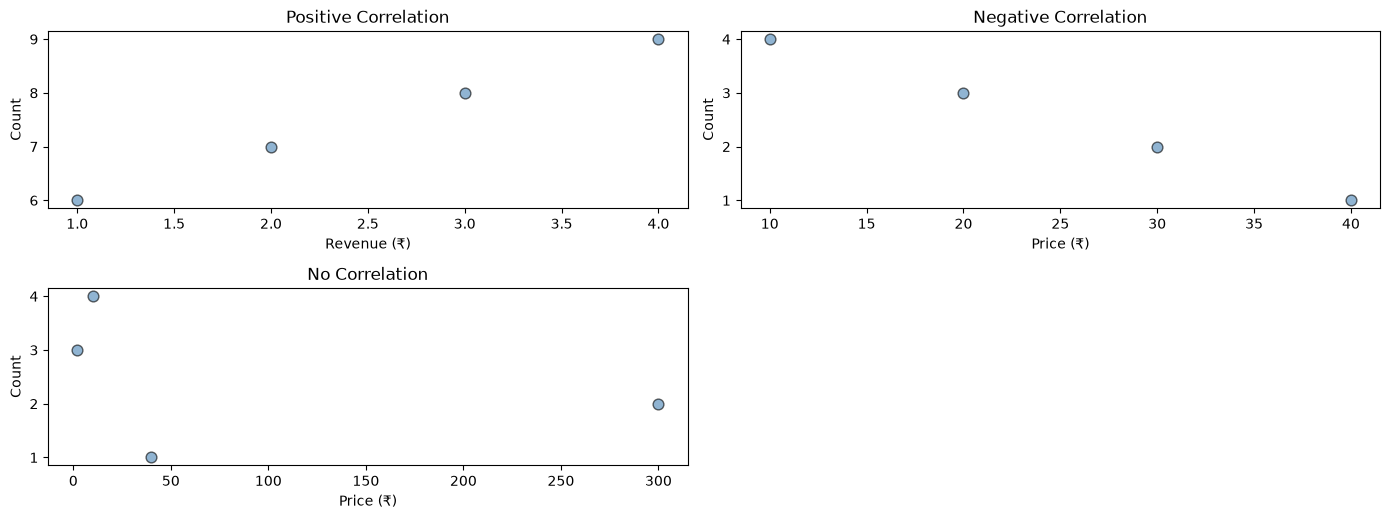

In [73]:
# ============================================
# OPTIONAL: Subplots — 2 charts side by side
# ============================================

plt.figure(figsize=(14, 10))

# ---- Chart 1 (left side) ----
plt.subplot(4, 2, 1)  # 1 row, 2 columns, position 1
x=[1,2,3,4]
y=[6,7,8,9]
plt.scatter(x,y ,s=60, color='steelblue',alpha=0.6, edgecolor='black')
plt.xlabel('Revenue (₹)')
plt.ylabel('Count')
plt.title('Positive Correlation')

# ---- Chart 2 (right side) ----
plt.subplot(4, 2, 2)  # 1 row, 2 columns, position 2
x=[10,20,30,40]
y=[4,3,2,1]
plt.scatter(x,y ,s=60, color='steelblue',alpha=0.6, edgecolor='black')
plt.xlabel('Price (₹)')
plt.ylabel('Count')
plt.title('Negative Correlation')

plt.subplot(4, 2, 3)  # 1 row, 2 columns, position 2
x=[10,2,300,40]
y=[4,3,2,1]
plt.scatter(x,y ,s=60, color='steelblue',alpha=0.6, edgecolor='black')
plt.xlabel('Price (₹)')
plt.ylabel('Count')
plt.title('No Correlation')

plt.tight_layout()
plt.show()

---

## 14. How to Write Business Insights from Charts

This is one of the **most important skills** in data science. Creating charts is only half the job — the other half is **explaining what the chart tells us**.

### The 3-Step Insight Formula:

| Step | Question to Ask | Example |
|---|---|---|
| 1. **What does the chart show?** | Describe the data | "This bar chart shows total revenue for each product." |
| 2. **What pattern do you see?** | Highlight trends, comparisons, outliers | "Laptop has the highest revenue, followed by Smartphone." |
| 3. **Why does it matter?** | Connect to business impact | "The business should ensure Laptop inventory is always stocked." |

### ❌ Bad insight:
> *"The bar chart shows revenue."*

### ✅ Good insight:
> *"Laptop dominates revenue at ₹X, contributing Y% of total sales. Given its high margin, prioritizing Laptop marketing campaigns could boost overall profitability."*

### Practice:
Go back to each chart we created and try writing your own 1–2 line insight!

---

## 15. Quick Reference — Chart Selection Guide

| Question Type | Chart Type | Matplotlib Function |
|---|---|---|
| How does it change **over time**? | Line Chart | `plt.plot()` |
| Which one is **bigger/smaller**? | Bar Chart | `plt.bar()` or `plt.barh()` |
| Is there a **relationship** between two numbers? | Scatter Plot | `plt.scatter()` |
| How is the data **distributed**? | Histogram | `plt.hist()` |
| Are there **outliers**? | Boxplot | `plt.boxplot()` |

**Remember:** Always add `xlabel`, `ylabel`, `title`, and `grid` to make your charts professional!

---

## 📝 Practice Questions

Try these on your own using the same Retail Sales dataset:

1. **Line Chart:** Plot the daily total quantity sold over time. Add title, labels, and grid.

2. **Bar Chart:** Create a bar chart showing the **average revenue** per product (not total — use `.mean()` instead of `.sum()`). Which product has the highest average revenue?

3. **Bar Chart:** Create a horizontal bar chart showing the **number of transactions** per product (use `value_counts()`).

4. **Scatter Plot:** Create a scatter plot of `Quantity` vs `Price`. Is there any relationship?

5. **Histogram:** Plot the distribution of `Quantity` with `bins=5`. Is the distribution uniform or skewed?

6. **Boxplot:** Create a boxplot of `Price`. Are there any price outliers?

7. **Insight Writing:** For **any 2 charts** you created above, write a 2-line business insight using the 3-step formula (What → Pattern → Business Impact).

8. **Combined Chart:** Create a line chart showing daily average price over time. Add a descriptive title and grid.

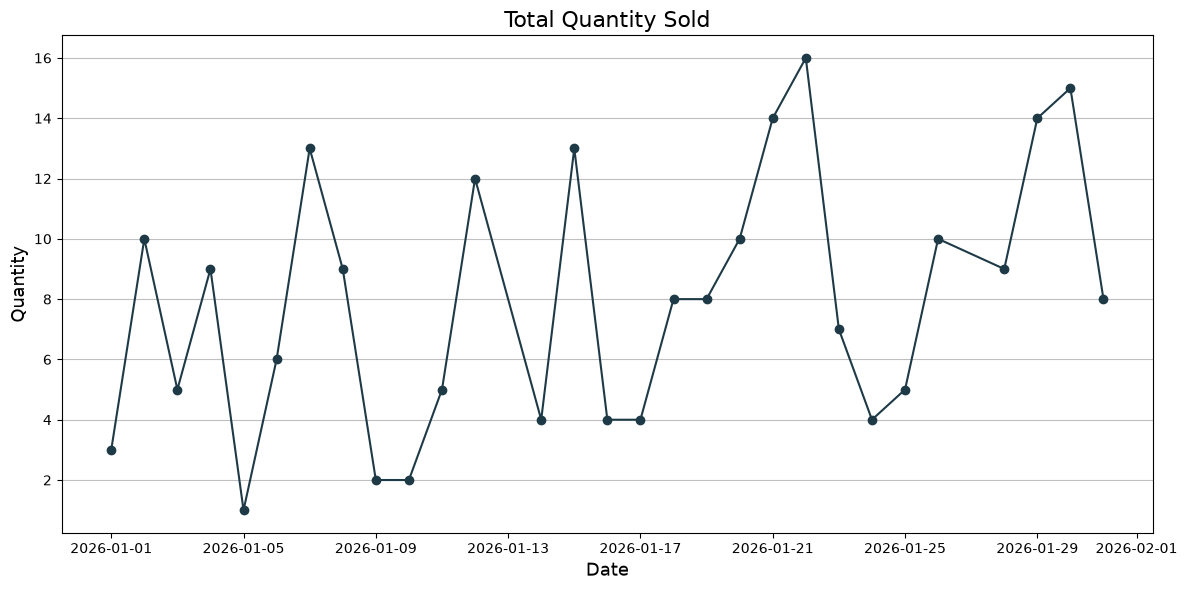

In [104]:
# ============================================
# YOUR PRACTICE SPACE — Question 1
# ============================================
daily_quantity = (
    df.groupby("Date")["Quantity"].sum()
)
plt.figure(figsize=(12,6))
plt.plot(daily_quantity.index, daily_quantity.values, color = "#1E3A47", marker = 'o')

plt.xlabel("Date", fontsize = 13)
plt.ylabel("Quantity", fontsize = 13)
plt.title("Total Quantity Sold", fontsize = 16)

plt.tight_layout()
plt.grid(axis='y', alpha = 0.8)
plt.show()


Product
Headphones     300.000000
Laptop        2857.142857
Smartphone    2072.727273
Smartwatch     562.500000
Tablet        1088.888889
Name: Revenue, dtype: float64


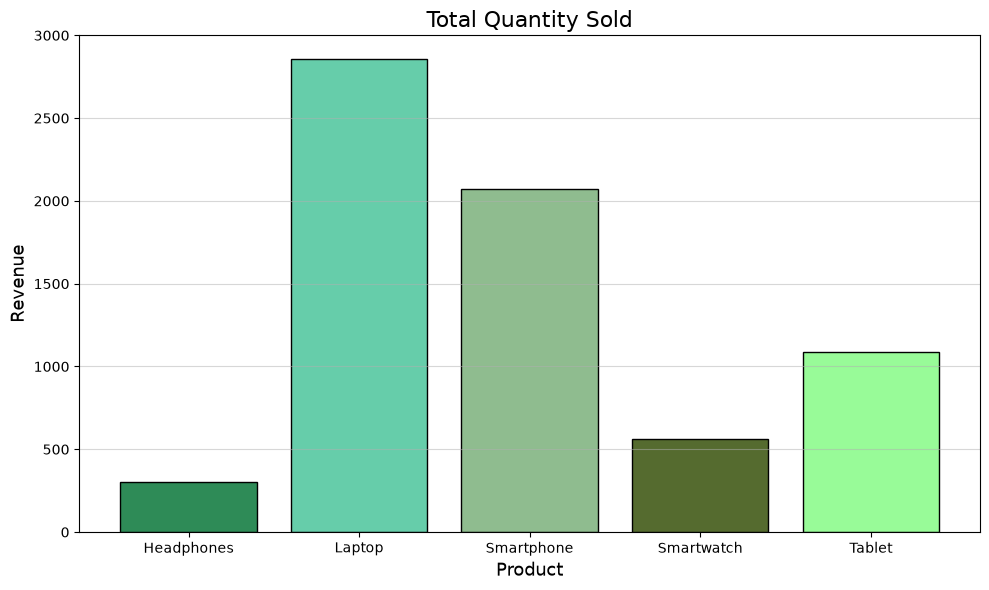

In [105]:
# ============================================
# YOUR PRACTICE SPACE — Question 2
# ============================================
#  Create a bar chart showing the **average revenue** per product (not total — use `.mean()` instead of `.sum()`). Which product has the highest average revenue?

average_product = (df.groupby('Product')['Revenue'].mean())

print(average_product)

colors = ['#2E8B57', '#66CDAA', '#8FBC8F', '#556B2F', '#98FB98']
plt.figure(figsize=(10,6))
plt.bar(average_product.index, average_product.values, color = colors, edgecolor = 'black')

plt.xlabel("Product", fontsize = 13)
plt.ylabel("Revenue", fontsize = 13)
plt.title("Total Quantity Sold", fontsize = 16)

plt.tight_layout()
plt.grid(axis='y', alpha = 0.5)
plt.show()
                   


Product
Laptop        21
Headphones    19
Tablet        18
Smartwatch    16
Smartphone    11
Name: count, dtype: int64


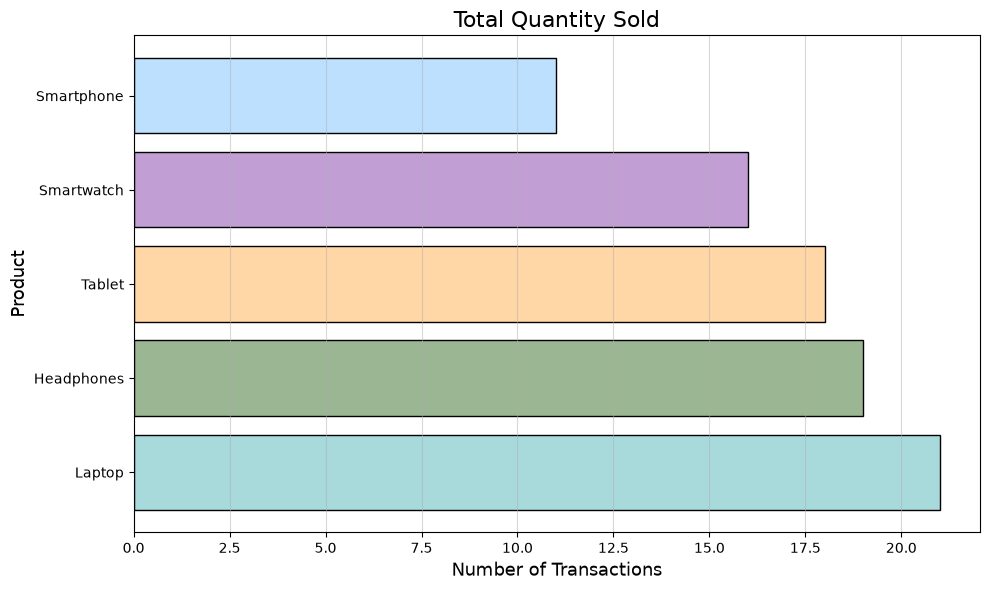

In [106]:
# ============================================
# YOUR PRACTICE SPACE — Question 3
# ============================================

# **Bar Chart:** Create a horizontal bar chart showing the **number of transactions** per product (use `value_counts()`).
transaction_number = (df['Product'].value_counts())

print(transaction_number)

colors = ['#A8DADC', "#9BB693", '#FFD6A5', "#C19FD4", '#BDE0FE']
plt.figure(figsize=(10,6))
plt.barh(transaction_number.index,transaction_number.values, color = colors, edgecolor = 'black')

plt.ylabel("Product", fontsize = 13)
plt.xlabel("Number of Transactions", fontsize = 13)
plt.title("Total Quantity Sold", fontsize = 16)

plt.tight_layout()
plt.grid(axis='x', alpha = 0.5)
plt.show()


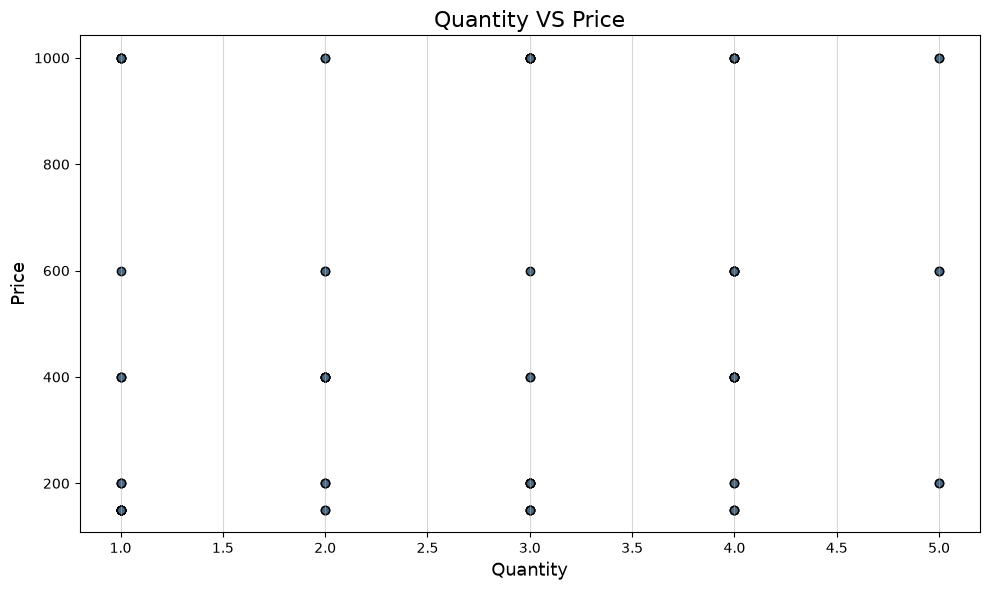

In [108]:
# ============================================
# YOUR PRACTICE SPACE — Question 4
# ============================================
# **Scatter Plot:** Create a scatter plot of `Quantity` vs `Price`. Is there any relationship?

plt.figure(figsize=(10,6))
plt.scatter(df['Quantity'], df['Price'], color = "#49667F", edgecolors='black')

plt.xlabel("Quantity", fontsize = 13)
plt.ylabel("Price", fontsize = 13)
plt.title("Quantity VS Price", fontsize = 16)

plt.tight_layout()
plt.grid(axis='x', alpha = 0.5)
plt.show()

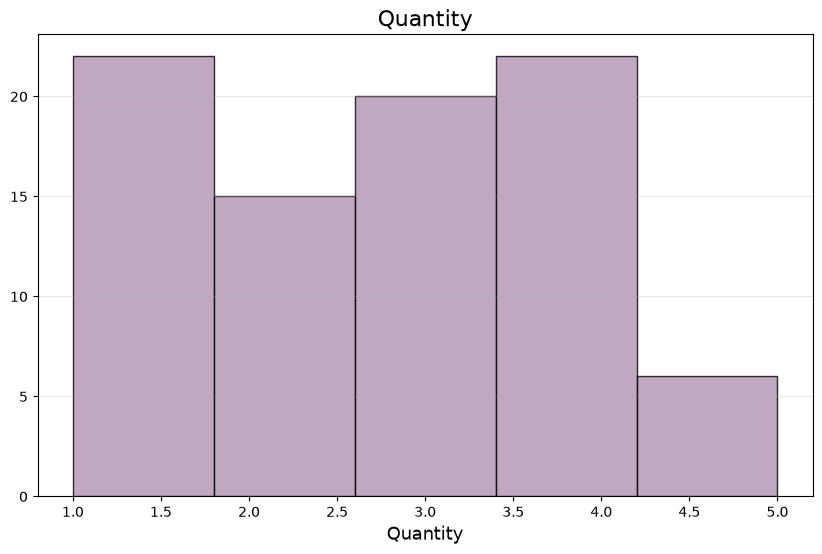

In [114]:
# ============================================
# YOUR PRACTICE SPACE — Question 5
# ============================================
# **Histogram:** Plot the distribution of `Quantity` with `bins=5`. Is the distribution uniform or skewed?

plt.figure(figsize=(10,6))
plt.hist(df['Quantity'], bins = 5, color = "#AF93B1", edgecolor='black', alpha=0.8)

plt.xlabel("Quantity", fontsize = 13)
# plt.ylabel("Price", fontsize = 13)
plt.title("Quantity", fontsize = 16)

plt.grid(axis='y', alpha = 0.3)
plt.show()




In [79]:
# ============================================
# YOUR PRACTICE SPACE — Question 6
# ============================================

# Write your code here


In [80]:
# ============================================
# YOUR PRACTICE SPACE — Question 7 (Insights)
# ============================================

# Write your insights as comments:
#
# Chart 1 Insight:
# ...
#
# Chart 2 Insight:
# ...


In [81]:
# ============================================
# YOUR PRACTICE SPACE — Question 8
# ============================================

# Write your code here


---

## 🎯 Assignment: Mini Visualization Report

**Objective:** Create a mini visualization report for the Retail Sales dataset.

**Instructions:**

1. Create the following 4 charts using the Retail Sales dataset:
   - A **line chart** showing total revenue by day
   - A **bar chart** showing average quantity sold per product
   - A **histogram** showing the distribution of revenue
   - A **boxplot** comparing revenue across products (create 5 separate lists, one per product)

2. For **each chart**, ensure you have:
   - Proper `figsize`
   - `xlabel`, `ylabel`, and `title`
   - `grid`

3. After **each chart**, write a **2–3 sentence business insight** explaining:
   - What the chart shows
   - What pattern you observe
   - One business recommendation

**Submission:** Complete the assignment in a new notebook or in the cells below.

---

## ✅ Summary

In this notebook, we learned:

| Topic | What We Covered |
|---|---|
| **Why Visualize** | Charts reveal patterns that tables hide |
| **Line Chart** | For trends over time (`plt.plot()`) |
| **Bar Chart** | For comparing categories (`plt.bar()`) |
| **Scatter Plot** | For relationships between numbers (`plt.scatter()`) |
| **Histogram** | For data distribution (`plt.hist()`) |
| **Boxplot** | For outlier detection (`plt.boxplot()`) |
| **Professional charts** | Always add `xlabel`, `ylabel`, `title`, `legend`, `grid` |
| **Business insights** | What → Pattern → Business Impact |

**Next up:** Seaborn — create the same charts with less code and better styling! 🎨

In [82]:
# ============================================
# YOUR ASSIGNMENT SPACE
# ============================================

# Chart 1: Line chart — Total revenue by day


# Chart 2: Bar chart — Average quantity per product


# Chart 3: Histogram — Revenue distribution


# Chart 4: Boxplot — Revenue by product
